# My First Blog

Hello everyone, welcome to my first blog. I am Sri Ganesh S. 
I am writing this blog to learn and improve my technical skills and to provide my own thoughts on the things I learn, so that the next person who follows my path can gain a new perspective on various things.

Every single one of my blogs is going to be my own journal in my path to complete the fast.ai course Part 1 and Part 2(https://course.fast.ai/). I would like to give a Huge thanks to Jeremy Howard and the fast.ai team for creating a fantastic course. 

## About me

Let me introduce myself again, I am Sri Ganesh S, pursuing my Master of IT @ UNSW Sydney. I am currently in my first term. and still have 5 more tri-mesters to complete my degree. I have done my Bachelors in Computer Science and Engineering in MSEC, India. 

## Pre-requisites

I would like to point out that, anyone can follow my blog comfortably in

- Basic python syntax
- Comfortable in basic high school calculus (Just need knowledge on what intergration and deferntiation does)
- a local environment to run all libraries in fastai course. (Eg: nbdev, kagglehub, fastai etc)

I would also highly recommend you to follow the course along with me to gain the most amount of knowledge from my blogs. So without further ado legs begin

# Making a model putting it in production

This notebook was written after Part 1 Lesson 2 pf the fast ai course
In this notebook I create a model to differentiate between a car and a truck in a given image.

In [2]:
from fastai import *
from fastai.vision.all import *
from pathlib import Path
import kagglehub
from fastai.vision.widgets import *

ModuleNotFoundError: No module named 'kagglehub'

In [1]:
kagglehub.login()

NameError: name 'kagglehub' is not defined

In [54]:
path = kagglehub.dataset_download("enesumcu/car-and-truck",output_dir="Data/car_or_truck")
print("Path to dataset files:", path)

Path to dataset files: Data/car_or_truck


In [71]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)

[None]

In [72]:
failed = verify_images(get_image_files(path))
len(failed)

0

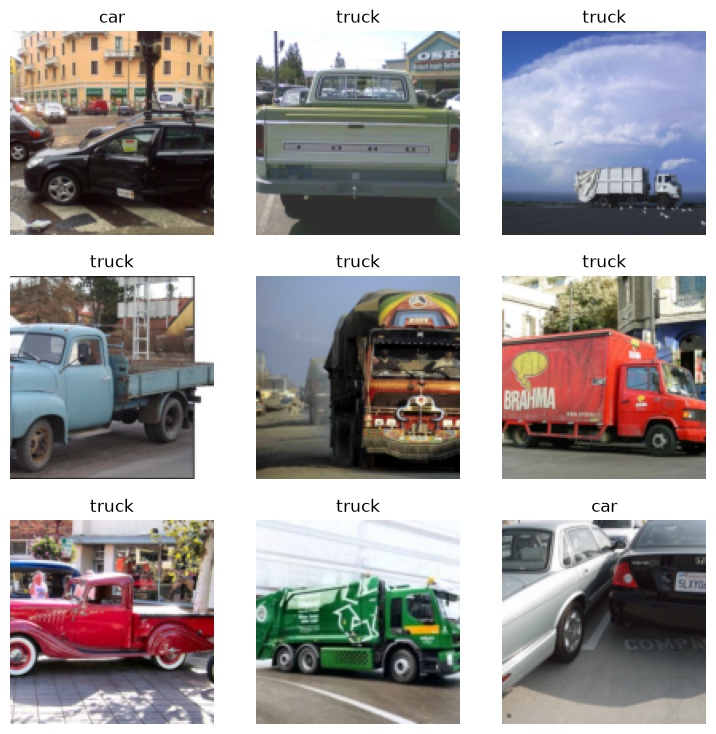

In [78]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms= Resize(128)).dataloaders(data_path)

dls.train.show_batch()

In [79]:
learn = vision_learner(dls, resnet18, metrics=error_rate)

In [80]:
learn.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,0.956962,0.573918,0.191083,00:01


epoch,train_loss,valid_loss,error_rate,time
0,0.526498,0.415896,0.165605,00:01
1,0.387070,0.495136,0.140127,00:01
2,0.290261,0.500073,0.152866,00:02
3,0.252708,0.461796,0.146497,00:02


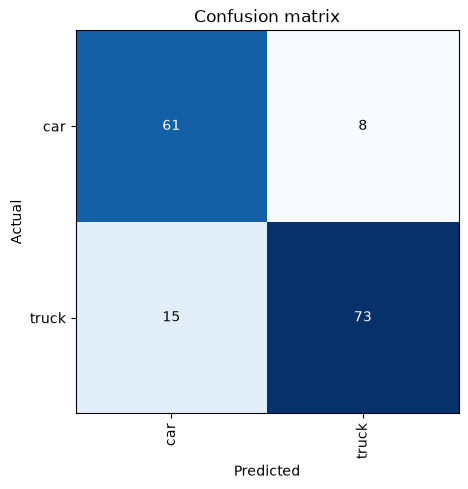

In [85]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

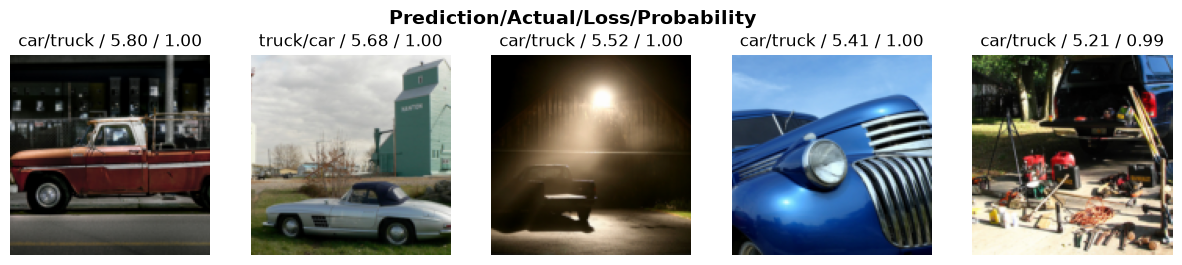

In [86]:
interp.plot_top_losses(5, nrows=1)

In [91]:
cleaner = ImageClassifierCleaner(learn)
cleaner

In [94]:
for idx in cleaner.delete(): cleaner.fns[idx].unlink

In [102]:
for idx,cat in cleaner.change(): shutil.move(cleaner.fns[idx],data_path/cat)

Error: Destination path 'Data/car_or_truck/datasets/Datasets/car/433793461.jpg' already exists

In [101]:
cleaner.fns[0]

Path('Data/car_or_truck/datasets/Datasets/truck/433466152.jpg')